DATASET INFORMATION
Shape : (21263, 82)

Top Correlated Features
                                                 Feature  Correlation  \
wtd_std_ThermalConductivity  wtd_std_ThermalConductivity     0.721271   
range_ThermalConductivity      range_ThermalConductivity     0.687654   
range_atomic_radius                  range_atomic_radius     0.653759   
std_ThermalConductivity          std_ThermalConductivity     0.653632   
wtd_mean_Valence                        wtd_mean_Valence    -0.632401   
wtd_entropy_atomic_mass          wtd_entropy_atomic_mass     0.626930   
wtd_gmean_Valence                      wtd_gmean_Valence    -0.615653   
wtd_entropy_atomic_radius      wtd_entropy_atomic_radius     0.603494   
number_of_elements                    number_of_elements     0.601069   
range_fie                                      range_fie     0.600790   
mean_Valence                                mean_Valence    -0.600085   
wtd_std_atomic_radius              wtd_std_atomic_radius   

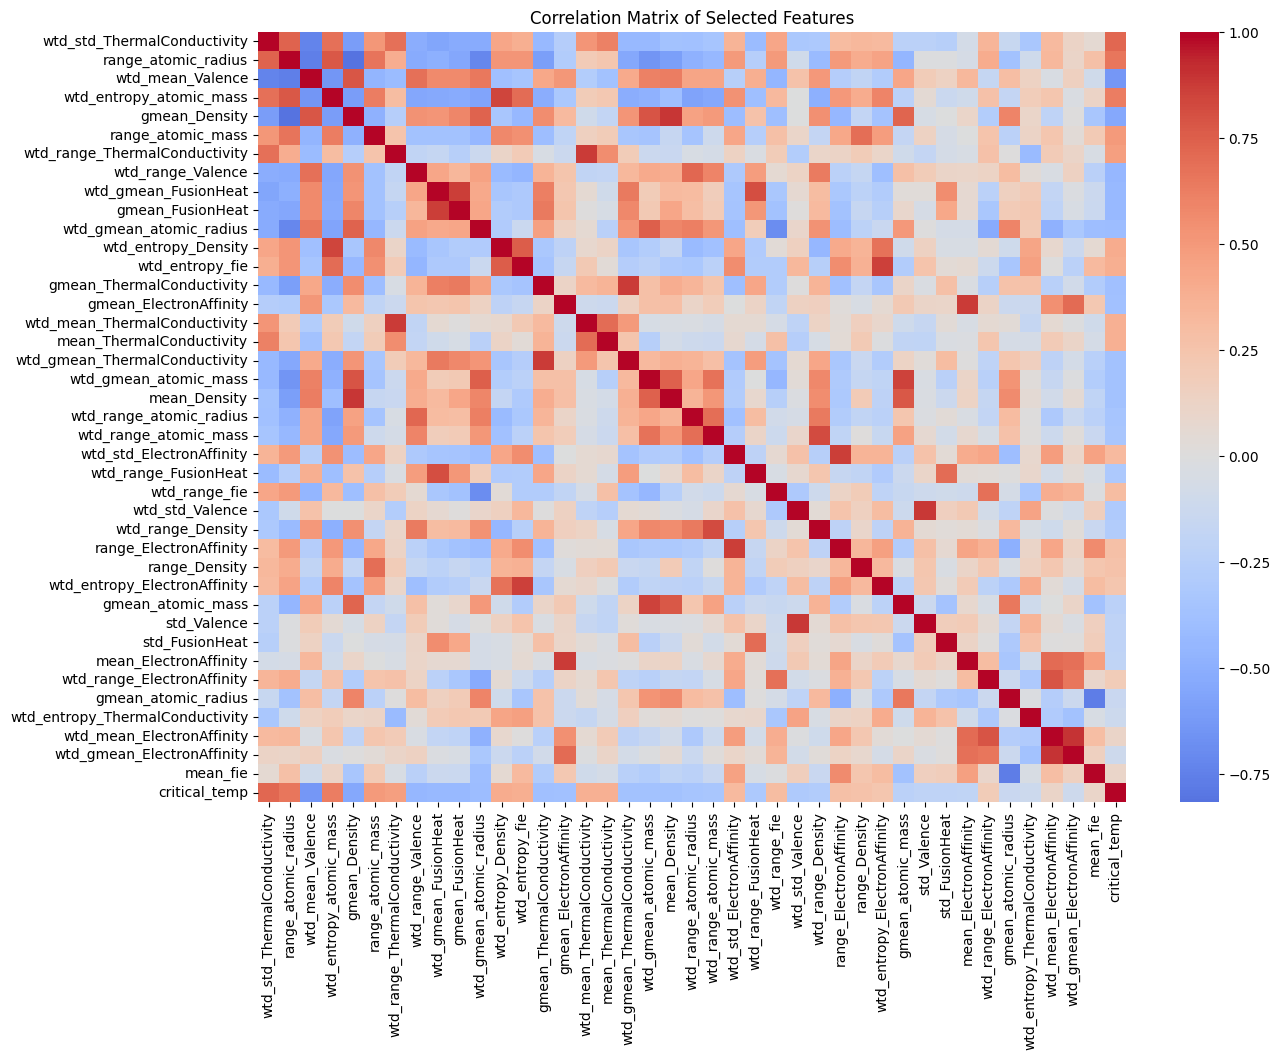



DECISION TREE PERFORMANCE
MAE           : 7.3096
MSE           : 138.0695
RMSE          : 11.7503
R2 Score      : 0.8801
Adjusted R2   : 0.8789
MAPE          : 1.7641


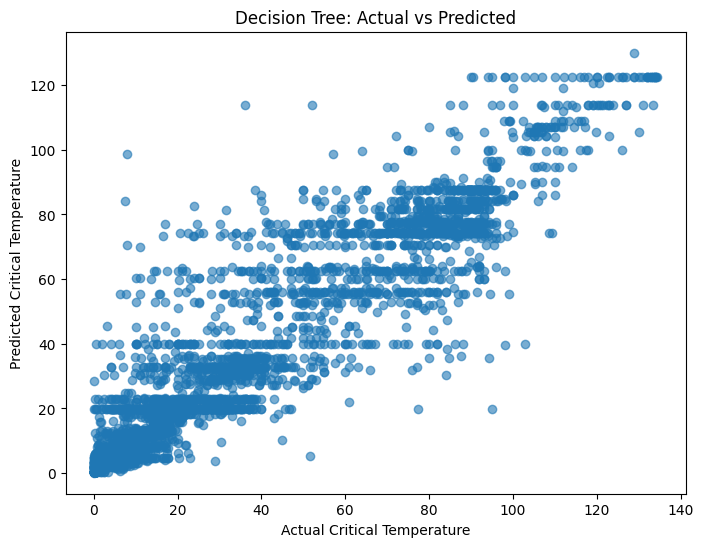

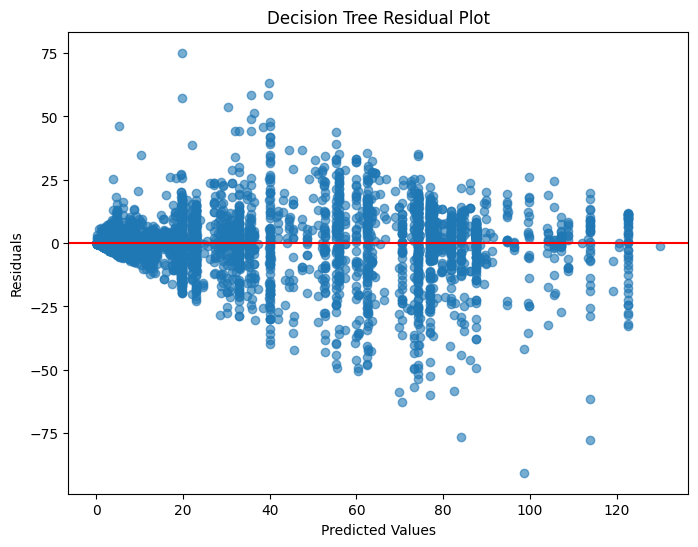



FEATURE IMPORTANCE
                            Feature  Importance
1               range_atomic_radius    0.569804
15     wtd_mean_ThermalConductivity    0.163487
2                  wtd_mean_Valence    0.041187
22         wtd_std_ElectronAffinity    0.039851
4                     gmean_Density    0.024705
7                 wtd_range_Valence    0.022107
5                 range_atomic_mass    0.012632
21            wtd_range_atomic_mass    0.010854
8              wtd_gmean_FusionHeat    0.010377
16         mean_ThermalConductivity    0.009893
24                    wtd_range_fie    0.008764
3           wtd_entropy_atomic_mass    0.006820
12                  wtd_entropy_fie    0.006475
10          wtd_gmean_atomic_radius    0.005489
13        gmean_ThermalConductivity    0.005367
28                    range_Density    0.005044
14           gmean_ElectronAffinity    0.004713
25                  wtd_std_Valence    0.004601
29     wtd_entropy_ElectronAffinity    0.004541
34       wtd_range_

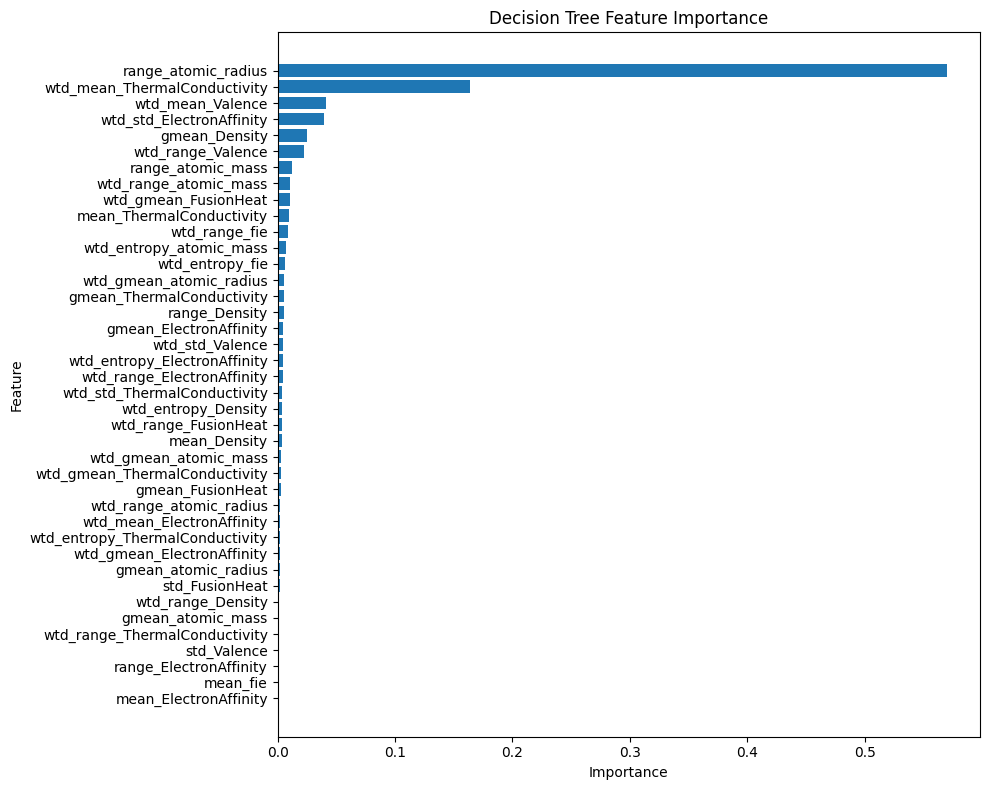

In [2]:
# ============================================================
# SUPERCONDUCTOR CRITICAL TEMPERATURE PREDICTION
# DECISION TREE REGRESSOR
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("train.csv")

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Shape :", df.shape)

# ============================================================
# 2. TARGET VARIABLE
# ============================================================

target = "critical_temp"

# ============================================================
# 3. INPUT AND OUTPUT
# ============================================================

X = df.drop(columns=[target])
y = df[target]

# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

X = X.fillna(X.median())
y = y.fillna(y.median())

# ============================================================
# 5. FEATURE SELECTION USING CORRELATION
# ============================================================

correlation = X.corrwith(y)

correlation_table = pd.DataFrame({
    "Feature": X.columns,
    "Correlation": correlation,
    "Absolute_Correlation": abs(correlation)
})

correlation_table = correlation_table.sort_values(
    by="Absolute_Correlation",
    ascending=False
)

print("\nTop Correlated Features")
print(correlation_table.head(20))

# ============================================================
# 6. SELECT IMPORTANT FEATURES
# ============================================================

threshold = 0.10

important_features = correlation_table[
    correlation_table["Absolute_Correlation"] >= threshold
]["Feature"].tolist()

print("\nNumber of Important Features:",
      len(important_features))

X = X[important_features]

# ============================================================
# 7. REMOVE MULTICOLLINEAR FEATURES
# ============================================================

corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

drop_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]

print("\nFeatures Removed due to Multicollinearity:")
print(drop_features)

X = X.drop(columns=drop_features)

print("\nFinal Feature Count:", X.shape[1])

# ============================================================
# 8. CORRELATION MATRIX
# ============================================================

final_df = pd.concat([X, y], axis=1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    final_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Selected Features")
plt.show()

# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ============================================================
# 10. DECISION TREE REGRESSOR
# ============================================================

model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

# ============================================================
# 11. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 12. EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (
    ((1 - r2) * (n - 1))
    /
    (n - p - 1)
)

print("\n")
print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print(f"MAE           : {mae:.4f}")
print(f"MSE           : {mse:.4f}")
print(f"RMSE          : {rmse:.4f}")
print(f"R2 Score      : {r2:.4f}")
print(f"Adjusted R2   : {adj_r2:.4f}")
print(f"MAPE          : {mape:.4f}")

# ============================================================
# 13. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Critical Temperature")
plt.ylabel("Predicted Critical Temperature")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

# ============================================================
# 14. RESIDUAL PLOT
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Decision Tree Residual Plot")

plt.show()

# ============================================================
# 15. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n")
print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(importance)

# ============================================================
# 16. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Decision Tree Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()